In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from LLS import LLS
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

In [65]:
data = pd.read_csv("Dollar_Rial_Price_Dataset.csv")
data.head()

,Unnamed: 0,Date,Persian_Date,Open,Low,High,Close
0,0,11/27/2011,1390/09/06,"13,700","13,700","13,700","13,700"
1,1,11/28/2011,1390/09/07,"13,440","13,440","13,440","13,440"
2,2,11/29/2011,1390/09/08,"13,350","13,350","13,350","13,350"
3,3,11/30/2011,1390/09/09,"13,400","13,400","13,400","13,400"
4,4,12/1/2011,1390/09/10,"13,500","13,500","13,500","13,500"


In [66]:
data["Date_LLS"] = data["Date"].str.replace("/", "").astype(int)
data["Date"] = pd.to_datetime(data["Date"])
data["Low"] = data["Low"].str.replace(",","").astype(int)
data["High"] = data["High"].str.replace(",","").astype(int)
data["Close"] = data["Close"].str.replace(",","").astype(int)
data.sort_values(by=["Date"], ascending=True).head()

,Unnamed: 0,Date,Persian_Date,Open,Low,High,Close,Date_LLS
0,0,2011-11-27,1390/09/06,"13,700",13700,13700,13700,11272011
1,1,2011-11-28,1390/09/07,"13,440",13440,13440,13440,11282011
2,2,2011-11-29,1390/09/08,"13,350",13350,13350,13350,11292011
3,3,2011-11-30,1390/09/09,"13,400",13400,13400,13400,11302011
4,4,2011-12-01,1390/09/10,"13,500",13500,13500,13500,1212011


In [67]:
#دوران ریاست جمهوری احمدی نژاد
#Start : 1390/09/06
#End : 1392/05/12
start_date_ahmadi_nejad = data[data["Persian_Date"] == "1390/09/06"].iloc[0]["Date"]
end_date_ahmadi_nejad = data[data["Persian_Date"] == "1392/05/12"].iloc[0]["Date"]
ahmadi_nejad_data = data[data["Date"].between(start_date_ahmadi_nejad,
                                              end_date_ahmadi_nejad)]
ahmadi_nejad_data.head()

,Unnamed: 0,Date,Persian_Date,Open,Low,High,Close,Date_LLS
0,0,2011-11-27,1390/09/06,"13,700",13700,13700,13700,11272011
1,1,2011-11-28,1390/09/07,"13,440",13440,13440,13440,11282011
2,2,2011-11-29,1390/09/08,"13,350",13350,13350,13350,11292011
3,3,2011-11-30,1390/09/09,"13,400",13400,13400,13400,11302011
4,4,2011-12-01,1390/09/10,"13,500",13500,13500,13500,1212011


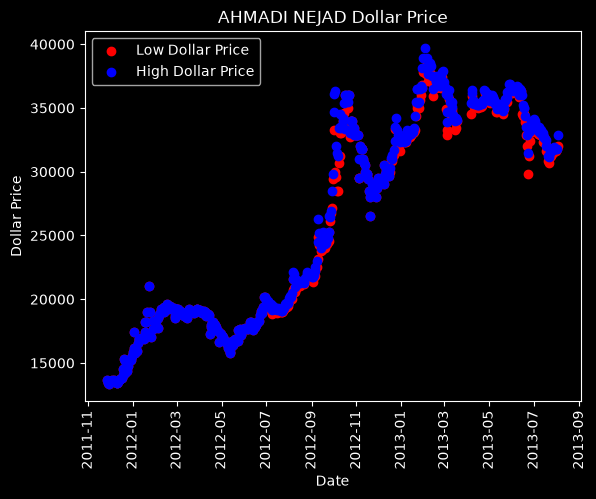

In [68]:
plt.scatter(ahmadi_nejad_data["Date"],ahmadi_nejad_data["Low"],color="red")
plt.scatter(ahmadi_nejad_data["Date"],ahmadi_nejad_data["High"],color="blue")
plt.title("AHMADI NEJAD Dollar Price")
plt.xlabel("Date")
plt.xticks(rotation=90)
plt.ylabel("Dollar Price")
plt.legend(["Low Dollar Price","High Dollar Price"],loc="upper left")
plt.show()

In [69]:
#دوران ریاست جمهوری روحانی
#Start : 1392/05/12
#End : 1400/05/12
start_date_rohani = data[data["Persian_Date"] == "1392/05/12"].iloc[0]["Date"]
end_date_rohani = data[data["Persian_Date"] == "1400/05/12"].iloc[0]["Date"]
rohani_data = data[data["Date"].between(start_date_rohani,
                                              end_date_rohani)]
rohani_data.head()

,Unnamed: 0,Date,Persian_Date,Open,Low,High,Close,Date_LLS
482,482,2013-08-03,1392/05/12,"32,100",32050,32900,32850,832013
483,483,2013-08-04,1392/05/13,"32,650",32400,32800,32400,842013
484,484,2013-08-05,1392/05/14,"32,150",31900,32200,32000,852013
485,485,2013-08-06,1392/05/15,"31,900",31750,31950,31900,862013
486,486,2013-08-07,1392/05/16,"32,050",32050,32350,32250,872013


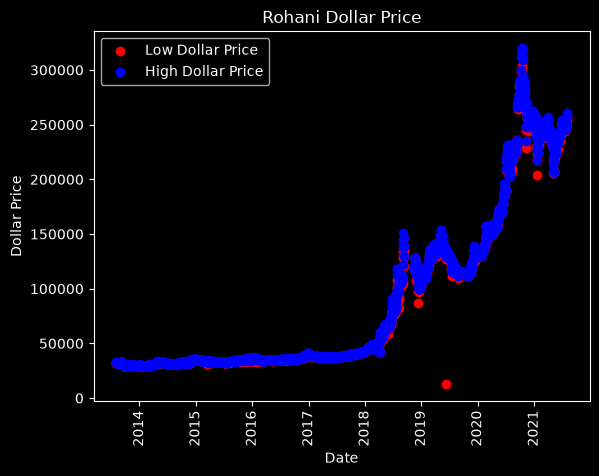

In [70]:
plt.scatter(rohani_data["Date"],rohani_data["Low"],color="red")
plt.scatter(rohani_data["Date"],rohani_data["High"],color="blue")
plt.title("Rohani Dollar Price")
plt.xlabel("Date")
plt.xticks(rotation=90)
plt.ylabel("Dollar Price")
plt.legend(["Low Dollar Price","High Dollar Price"],loc="upper left")
plt.show()

In [71]:
data.sort_values(by=["Date"], ascending=False).head()

,Unnamed: 0,Date,Persian_Date,Open,Low,High,Close,Date_LLS
3309,3309,2023-07-05,1402/04/14,"499,030",498400,501400,500950,752023
3308,3308,2023-07-04,1402/04/13,"502,140",498300,502200,500750,742023
3307,3307,2023-07-03,1402/04/12,"503,210",501400,503400,502000,732023
3306,3306,2023-07-02,1402/04/11,"500,810",498600,500900,499340,722023
3305,3305,2023-07-01,1402/04/10,"492,660",492600,498400,498220,712023


In [72]:
#دوران ریاست جمهوری رئیسی
#Start : 1400/05/12
#End : 1402/04/14
start_date_raisi = data[data["Persian_Date"] == "1400/05/12"].iloc[0]["Date"]
end_date_raisi = data[data["Persian_Date"] == "1402/04/14"].iloc[0]["Date"]
raisi_data = data[data["Date"].between(start_date_raisi,
                                              end_date_raisi)]
raisi_data.head()

,Unnamed: 0,Date,Persian_Date,Open,Low,High,Close,Date_LLS
2857,2857,2021-08-03,1400/05/12,"255,790",255690,258140,257290,832021
2858,2858,2021-08-04,1400/05/13,"257,250",254690,257340,256190,842021
2859,2859,2021-08-05,1400/05/14,"256,490",255790,256740,256190,852021
2860,2860,2021-08-07,1400/05/16,"254,190",253990,257140,256380,872021
2861,2861,2021-08-08,1400/05/17,"256,290",252390,257440,256890,882021


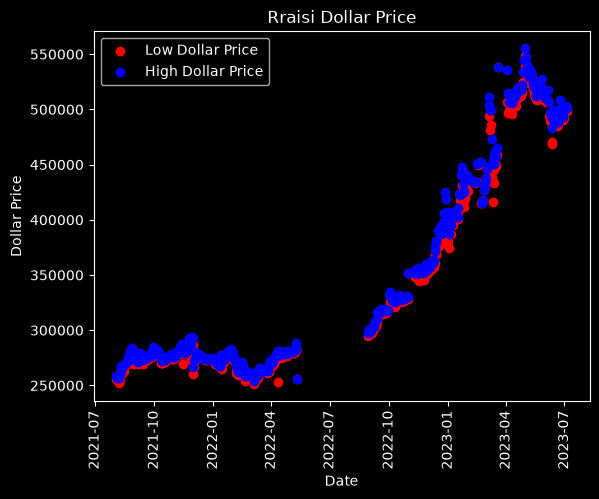

In [73]:
plt.scatter(raisi_data["Date"],raisi_data["Low"],color="red")
plt.scatter(raisi_data["Date"],raisi_data["High"],color="blue")
plt.title("Rraisi Dollar Price")
plt.xlabel("Date")
plt.xticks(rotation=90)
plt.ylabel("Dollar Price")
plt.legend(["Low Dollar Price","High Dollar Price"],loc="upper left")
plt.show()

In [85]:
X_ahmadi = np.array(ahmadi_nejad_data["Date_LLS"])
X_rohani = np.array(rohani_data["Date_LLS"])
X_raisi = np.array(raisi_data["Date_LLS"])
Y_ahmadi = np.array(ahmadi_nejad_data["Close"])
Y_rohani = np.array(rohani_data["Close"])
Y_raisi = np.array(raisi_data["Close"])

In [86]:
#Ahmadi Nejad
X_train,X_test,Y_train,Y_test = train_test_split(X_ahmadi,Y_ahmadi,test_size=0.2)
Y_train = Y_train.reshape(-1,1)
Y_test = Y_test.reshape(-1,1)
X_train = X_train.reshape(-1,1)
X_test = X_test.reshape(-1,1)

In [87]:
lls_ahmadi = LLS()
lls_ahmadi.fit(X_train,Y_train)
loss_ahmadi = lls_ahmadi.evaluate(X_test,Y_test,metric="mae")
loss_ahmadi

np.float64(15191.020696580528)

In [88]:
#Rohani
X_train,X_test,Y_train,Y_test = train_test_split(X_rohani,Y_rohani,test_size=0.2)
Y_train = Y_train.reshape(-1,1)
Y_test = Y_test.reshape(-1,1)
X_train = X_train.reshape(-1,1)
X_test = X_test.reshape(-1,1)

In [89]:
lls_rohani = LLS()
lls_rohani.fit(X_train,Y_train)
loss_rohani = lls_rohani.evaluate(X_test,Y_test,metric="mae")
loss_rohani

np.float64(71627.48197882918)

In [90]:
#Raisi
X_train,X_test,Y_train,Y_test = train_test_split(X_raisi,Y_raisi,test_size=0.2)
Y_train = Y_train.reshape(-1,1)
Y_test = Y_test.reshape(-1,1)
X_train = X_train.reshape(-1,1)
X_test = X_test.reshape(-1,1)

In [91]:
lls_raisi = LLS()
lls_raisi.fit(X_train,Y_train)
loss_raisi = lls_raisi.evaluate(X_test,Y_test,metric="mae")
loss_raisi

np.float64(219512.72191568735)